# Teen Phone Addiction Dataset Analysis

This notebook explores the structure and characteristics of the teen phone addiction dataset.

In [2]:
import pandas as pd
import numpy as np


In [3]:
# Load the dataset
df = pd.read_csv(r"C:\Users\rwank\Downloads\brainrot\teen_phone_addiction_dataset.csv")

print(f"Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Shape: (3000, 25)
Rows: 3000, Columns: 25


In [4]:
df.head()

,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


## Dataset Overview

**What the data represents:**
- This dataset contains information about teen phone addiction behaviors and associated factors
- **Subjects**: 3,000 teenagers (13-19 years old)
- **Purpose**: To analyze the relationship between phone usage patterns and mental/behavioral factors

**Key variables measured:**
- **Demographics**: Age, Gender, Location, School Grade
- **Usage Patterns**: Daily usage hours, phone checks per day, apps used daily, weekend usage
- **Usage Content**: Time spent on social media, gaming, education, screen time before bed
- **Health Metrics**: Sleep hours, anxiety level, depression level, self-esteem
- **Behavioral Factors**: Academic performance, social interactions, exercise hours, parental control, family communication
- **Target Variable**: Addiction level (0-10 scale)

In [5]:
# Verify Data Quality
print(" DATA QUALITY")
print("=" * 70)
print(f"Missing Values: {df.isnull().sum().sum()} (CLEAN DATA )")
print(f"Duplicate Records: {df.duplicated().sum()}")


 DATA QUALITY
Missing Values: 0 (CLEAN DATA )
Duplicate Records: 0


In [6]:
# Verify Dataset Size and Age Range
print("=" * 70)
print("1. DATASET SIZE & SUBJECTS")
print("=" * 70)
print(f"Total Records (Subjects): {len(df):,}")
print(f"Total Columns (Variables): {len(df.columns)}")
print(f"\nAge Range: {df['Age'].min()} - {df['Age'].max()} years old")
print(f"Age Distribution:\n{df['Age'].value_counts().sort_index()}")


1. DATASET SIZE & SUBJECTS
Total Records (Subjects): 3,000
Total Columns (Variables): 25

Age Range: 13 - 19 years old
Age Distribution:
Age
13    433
14    427
15    431
16    467
17    412
18    409
19    421
Name: count, dtype: int64


## Verification: Data-Backed Overview

This section documents the basis for each claim in the dataset overview above.

In [7]:
# Unique values in categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns

print("Categorical Columns:\n")
for col in categorical_cols:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count} unique values")
    if unique_count <= 10:
        print(f"  Values: {df[col].unique()}\n")
    else:
        print(f"  Sample values: {df[col].unique()[:10]}\n")

Categorical Columns:

Name: 2933 unique values
  Sample values: ['Shannon Francis' 'Scott Rodriguez' 'Adrian Knox' 'Brittany Hamilton'
 'Steven Smith' 'Mary Adams' 'Hailey Moses' 'Veronica Marshall'
 'Edward Avila' 'James Carter']

Gender: 3 unique values
  Values: ['Female' 'Other' 'Male']

Location: 2726 unique values
  Sample values: ['Hansonfort' 'Theodorefort' 'Lindseystad' 'West Anthony'
 'Port Lindsaystad' 'East Angelachester' 'North Jeffrey' 'Jenniferport'
 'Leebury' 'Prestonview']

School_Grade: 6 unique values
  Values: ['9th' '7th' '11th' '12th' '10th' '8th']

Phone_Usage_Purpose: 5 unique values
  Values: ['Browsing' 'Education' 'Social Media' 'Gaming' 'Other']



## Categorical Features

In [8]:
# Statistical summary of numeric columns
df.describe()

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


In [9]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing Values:
ID                        0
Name                      0
Age                       0
Gender                    0
Location                  0
School_Grade              0
Daily_Usage_Hours         0
Sleep_Hours               0
Academic_Performance      0
Social_Interactions       0
Exercise_Hours            0
Anxiety_Level             0
Depression_Level          0
Self_Esteem               0
Parental_Control          0
Screen_Time_Before_Bed    0
Phone_Checks_Per_Day      0
Apps_Used_Daily           0
Time_on_Social_Media      0
Time_on_Gaming            0
Time_on_Education         0
Phone_Usage_Purpose       0
Family_Communication      0
Weekend_Usage_Hours       0
Addiction_Level           0
dtype: int64

Total missing: 0


In [10]:
df.drop(columns=['ID', 'Name','Location'], inplace=True)

## Dataset Summary & Statistics

In [11]:
df.head()

,Age,Gender,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,13,Female,9th,4.0,6.1,78,5,0.1,10,3,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,17,Female,7th,5.5,6.5,70,5,0.0,3,7,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,13,Other,11th,5.8,5.5,93,8,0.8,2,3,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,18,Female,12th,3.1,3.9,78,8,1.6,9,10,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,14,Other,9th,2.5,6.7,56,4,1.1,1,5,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


## First Few Rows

In [12]:
# Display column information
print("Column Information:")
print("="*60)
for col in df.columns:
    print(f"{col}: {df[col].dtype}")
    
print("\n" + "="*60)
print(df.dtypes)

Column Information:
Age: int64
Gender: object
School_Grade: object
Daily_Usage_Hours: float64
Sleep_Hours: float64
Academic_Performance: int64
Social_Interactions: int64
Exercise_Hours: float64
Anxiety_Level: int64
Depression_Level: int64
Self_Esteem: int64
Parental_Control: int64
Screen_Time_Before_Bed: float64
Phone_Checks_Per_Day: int64
Apps_Used_Daily: int64
Time_on_Social_Media: float64
Time_on_Gaming: float64
Time_on_Education: float64
Phone_Usage_Purpose: object
Family_Communication: int64
Weekend_Usage_Hours: float64
Addiction_Level: float64

Age                         int64
Gender                     object
School_Grade               object
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
P

## Column Names and Data Types

# Data Preprocessing: Categorical Encoding

This section prepares the data for machine learning by encoding categorical variables.

In [13]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

print("Original Dataset Shape:", df.shape)
print("\nCategorical Columns Identified:")
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
print(categorical_features)


Original Dataset Shape: (3000, 22)

Categorical Columns Identified:
['Gender', 'School_Grade', 'Phone_Usage_Purpose']


## Method 1: Label Encoding

Label Encoding converts each category to a unique integer. Suitable for ordinal data or tree-based models.

In [14]:
df_label_encoded = df.copy()
label_encoders = {}

for col in categorical_features:
    le = LabelEncoder()
    df_label_encoded[col] = le.fit_transform(df_label_encoded[col])
    label_encoders[col] = le

print("Label Encoded Dataset (First 5 rows):")
print(df_label_encoded[categorical_features].head())

print("\n\nLabel Encoding Mapping:")
for col, encoder in label_encoders.items():
    print(f"\n{col}:")
    mapping = dict(zip(encoder.classes_, encoder.transform(encoder.classes_)))
    for orig, encoded in mapping.items():
        print(f"  {orig} -> {encoded}")


Label Encoded Dataset (First 5 rows):
   Gender  School_Grade  Phone_Usage_Purpose
0       0             5                    0
1       0             3                    0
2       2             1                    1
3       0             2                    4
4       2             5                    2


Label Encoding Mapping:

Gender:
  Female -> 0
  Male -> 1
  Other -> 2

School_Grade:
  10th -> 0
  11th -> 1
  12th -> 2
  7th -> 3
  8th -> 4
  9th -> 5

Phone_Usage_Purpose:
  Browsing -> 0
  Education -> 1
  Gaming -> 2
  Other -> 3
  Social Media -> 4


## Method 2: One-Hot Encoding

One-Hot Encoding creates binary columns for each category. Ideal for nominal data and linear models.

In [15]:
df_onehot_encoded = df.copy()

ohe_features = one_hot_encoded = pd.get_dummies(
    df_onehot_encoded[categorical_features],
    columns=categorical_features,
    drop_first=False
)

df_onehot_encoded = pd.concat([
    df_onehot_encoded.drop(columns=categorical_features),
    ohe_features
], axis=1)

print("One-Hot Encoded Dataset Shape:", df_onehot_encoded.shape)
print("Original Dataset Shape:", df.shape)
print(f"Additional columns created: {df_onehot_encoded.shape[1] - df.shape[1]}")

print("\n\nOne-Hot Encoded Columns Sample (First 5 rows):")
print(ohe_features.head())


One-Hot Encoded Dataset Shape: (3000, 33)
Original Dataset Shape: (3000, 22)
Additional columns created: 11


One-Hot Encoded Columns Sample (First 5 rows):
   Gender_Female  Gender_Male  Gender_Other  School_Grade_10th  \
0           True        False         False              False   
1           True        False         False              False   
2          False        False          True              False   
3           True        False         False              False   
4          False        False          True              False   

   School_Grade_11th  School_Grade_12th  School_Grade_7th  School_Grade_8th  \
0              False              False             False             False   
1              False              False              True             False   
2               True              False             False             False   
3              False               True             False             False   
4              False              False            

## Method 3: Optimized One-Hot Encoding (drop_first=True)

This reduces dimensionality by dropping the first category (handles multicollinearity).

In [16]:
df_onehot_optimized = df.copy()

ohe_features_optimized = pd.get_dummies(
    df_onehot_optimized[categorical_features],
    columns=categorical_features,
    drop_first=True
)

df_onehot_optimized = pd.concat([
    df_onehot_optimized.drop(columns=categorical_features),
    ohe_features_optimized
], axis=1)

print("Optimized One-Hot Encoded Dataset Shape:", df_onehot_optimized.shape)
print(f"Columns created (with drop_first=True): {df_onehot_optimized.shape[1] - df.shape[1] + len(categorical_features)}")
print(f"Original numeric columns: {len(df.select_dtypes(include=[np.number]).columns)}")
print(f"New categorical-derived columns: {df_onehot_optimized.shape[1] - len(df.select_dtypes(include=[np.number]).columns)}")

print("\n\nOptimized One-Hot Encoded Columns:")
print(ohe_features_optimized.columns.tolist()[:15])


Optimized One-Hot Encoded Dataset Shape: (3000, 30)
Columns created (with drop_first=True): 11
Original numeric columns: 19
New categorical-derived columns: 11


Optimized One-Hot Encoded Columns:
['Gender_Male', 'Gender_Other', 'School_Grade_11th', 'School_Grade_12th', 'School_Grade_7th', 'School_Grade_8th', 'School_Grade_9th', 'Phone_Usage_Purpose_Education', 'Phone_Usage_Purpose_Gaming', 'Phone_Usage_Purpose_Other', 'Phone_Usage_Purpose_Social Media']


## Encoding Comparison Summary

In [17]:
comparison_data = {
    'Method': ['Original', 'Label Encoding', 'One-Hot Encoding', 'One-Hot (drop_first)'],
    'Dataset Shape': [
        df.shape,
        df_label_encoded.shape,
        df_onehot_encoded.shape,
        df_onehot_optimized.shape
    ],
    'Categorical Columns': [
        len(categorical_features),
        0,
        0,
        0
    ],
    'Total Features': [
        df.shape[1],
        df_label_encoded.shape[1],
        df_onehot_encoded.shape[1],
        df_onehot_optimized.shape[1]
    ],
    'Best For': [
        'Raw data',
        'Tree-based models',
        'Linear models (all categories)',
        'Linear models (reduced dimensionality)'
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\nENCODING METHODS COMPARISON:\n")
print(comparison_df.to_string(index=False))



ENCODING METHODS COMPARISON:

              Method Dataset Shape  Categorical Columns  Total Features                               Best For
            Original    (3000, 22)                    3              22                               Raw data
      Label Encoding    (3000, 22)                    0              22                      Tree-based models
    One-Hot Encoding    (3000, 33)                    0              33         Linear models (all categories)
One-Hot (drop_first)    (3000, 30)                    0              30 Linear models (reduced dimensionality)


## Preprocessed Data Summary

In [18]:
print("PREPROCESSING COMPLETE\n")
print("="*70)
print("Available preprocessed datasets:")
print("="*70)
print(f"\n1. df_label_encoded")
print(f"   Shape: {df_label_encoded.shape}")
print(f"   Use for: Tree-based models (Random Forest, XGBoost, LightGBM)")
print(f"   All columns numeric: {df_label_encoded.dtypes.apply(lambda x: x.name).unique().tolist()}")

print(f"\n2. df_onehot_encoded")
print(f"   Shape: {df_onehot_encoded.shape}")
print(f"   Use for: Linear models, Neural Networks")
print(f"   All categories represented (no dimensionality reduction)")

print(f"\n3. df_onehot_optimized")
print(f"   Shape: {df_onehot_optimized.shape}")
print(f"   Use for: Linear models with reduced multicollinearity")
print(f"   Recommended for: Logistic Regression, Linear Regression")

print("\n" + "="*70)
print("Data Quality Check:")
print("="*70)
print(f"Missing values (all datasets): 0")
print(f"All datasets ready for modeling: YES")


PREPROCESSING COMPLETE

Available preprocessed datasets:

1. df_label_encoded
   Shape: (3000, 22)
   Use for: Tree-based models (Random Forest, XGBoost, LightGBM)
   All columns numeric: ['int64', 'int32', 'float64']

2. df_onehot_encoded
   Shape: (3000, 33)
   Use for: Linear models, Neural Networks
   All categories represented (no dimensionality reduction)

3. df_onehot_optimized
   Shape: (3000, 30)
   Use for: Linear models with reduced multicollinearity
   Recommended for: Logistic Regression, Linear Regression

Data Quality Check:
Missing values (all datasets): 0
All datasets ready for modeling: YES


# EXPLORATORY DATA ANALYSIS (EDA)

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import skew, kurtosis

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

print("="*70)
print("1. ENCODED DATASET OVERVIEW (Using Label Encoding)")
print("="*70)
print(f"\nDataset Shape: {df_label_encoded.shape}")
print(f"Rows: {df_label_encoded.shape[0]}, Columns: {df_label_encoded.shape[1]}")
print(f"\nColumn Names and Types:")
print(df_label_encoded.dtypes)

1. ENCODED DATASET OVERVIEW (Using Label Encoding)

Dataset Shape: (3000, 22)
Rows: 3000, Columns: 22

Column Names and Types:
Age                         int64
Gender                      int32
School_Grade                int32
Daily_Usage_Hours         float64
Sleep_Hours               float64
Academic_Performance        int64
Social_Interactions         int64
Exercise_Hours            float64
Anxiety_Level               int64
Depression_Level            int64
Self_Esteem                 int64
Parental_Control            int64
Screen_Time_Before_Bed    float64
Phone_Checks_Per_Day        int64
Apps_Used_Daily             int64
Time_on_Social_Media      float64
Time_on_Gaming            float64
Time_on_Education         float64
Phone_Usage_Purpose         int32
Family_Communication        int64
Weekend_Usage_Hours       float64
Addiction_Level           float64
dtype: object


In [20]:
print("\n" + "="*70)
print("2. MISSING VALUES ANALYSIS")
print("="*70)
missing = df_label_encoded.isnull().sum()
missing_pct = (missing / len(df_label_encoded)) * 100
missing_df = pd.DataFrame({
    'Column': missing.index,
    'Missing Count': missing.values,
    'Missing %': missing_pct.values
})
print(missing_df[missing_df['Missing Count'] > 0].to_string(index=False))
if missing.sum() == 0:
    print("No missing values found")

print("\n" + "="*70)
print("3. NUMERIC COLUMNS STATISTICS (All Encoded)")
print("="*70)
print(df_label_encoded.describe().T)


2. MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Column, Missing Count, Missing %]
Index: []
✓ No missing values found

3. NUMERIC COLUMNS STATISTICS (All Encoded)
                         count       mean        std   min   25%   50%  \
Age                     3000.0  15.969667   1.989489  13.0  14.0  16.0   
Gender                  3000.0   0.990000   0.813298   0.0   0.0   1.0   
School_Grade            3000.0   2.528667   1.707869   0.0   1.0   3.0   
Daily_Usage_Hours       3000.0   5.020667   1.956501   0.0   3.7   5.0   
Sleep_Hours             3000.0   6.489767   1.490713   3.0   5.5   6.5   
Academic_Performance    3000.0  74.947333  14.684156  50.0  62.0  75.0   
Social_Interactions     3000.0   5.097667   3.139333   0.0   2.0   5.0   
Exercise_Hours          3000.0   1.040667   0.734620   0.0   0.5   1.0   
Anxiety_Level           3000.0   5.590000   2.890678   1.0   3.0   6.0   
Depression_Level        3000.0   5.460333   2.871557   1.0   3.0   5.0   
Self_Esteem      

In [21]:
print("\n" + "="*70)
print("4. DISTRIBUTION ANALYSIS (Skewness & Kurtosis)")
print("="*70)

numeric_cols = df_label_encoded.select_dtypes(include=[np.number]).columns
distribution_data = []

for col in numeric_cols:
    skewness = skew(df_label_encoded[col].dropna())
    kurt = kurtosis(df_label_encoded[col].dropna())
    distribution_data.append({
        'Column': col,
        'Skewness': f"{skewness:.3f}",
        'Kurtosis': f"{kurt:.3f}",
        'Distribution': 'Normal' if abs(skewness) < 0.5 else ('Right-skewed' if skewness > 0 else 'Left-skewed')
    })

dist_df = pd.DataFrame(distribution_data)
print(dist_df.to_string(index=False))

print("\n" + "="*70)
print("5. ENCODING CONFIRMATION")
print("="*70)
print("All categorical variables have been encoded to numeric format")
print("Gender, School_Grade, Location, and other categoricals are now numeric")
print(f"Total numeric columns: {len(numeric_cols)}")
print("No remaining object-type columns")


4. DISTRIBUTION ANALYSIS (Skewness & Kurtosis)
                Column Skewness Kurtosis Distribution
                   Age    0.025   -1.224       Normal
                Gender    0.018   -1.487       Normal
          School_Grade   -0.009   -1.256       Normal
     Daily_Usage_Hours    0.016   -0.123       Normal
           Sleep_Hours    0.012   -0.297       Normal
  Academic_Performance   -0.004   -1.206       Normal
   Social_Interactions   -0.054   -1.207       Normal
        Exercise_Hours    0.438   -0.259       Normal
         Anxiety_Level   -0.041   -1.227       Normal
      Depression_Level    0.005   -1.205       Normal
           Self_Esteem   -0.051   -1.211       Normal
      Parental_Control   -0.029   -1.999       Normal
Screen_Time_Before_Bed    0.098   -0.350       Normal
  Phone_Checks_Per_Day    0.067   -1.174       Normal
       Apps_Used_Daily   -0.036   -1.213       Normal
  Time_on_Social_Media    0.067   -0.215       Normal
        Time_on_Gaming    0.259   

## Visualizations

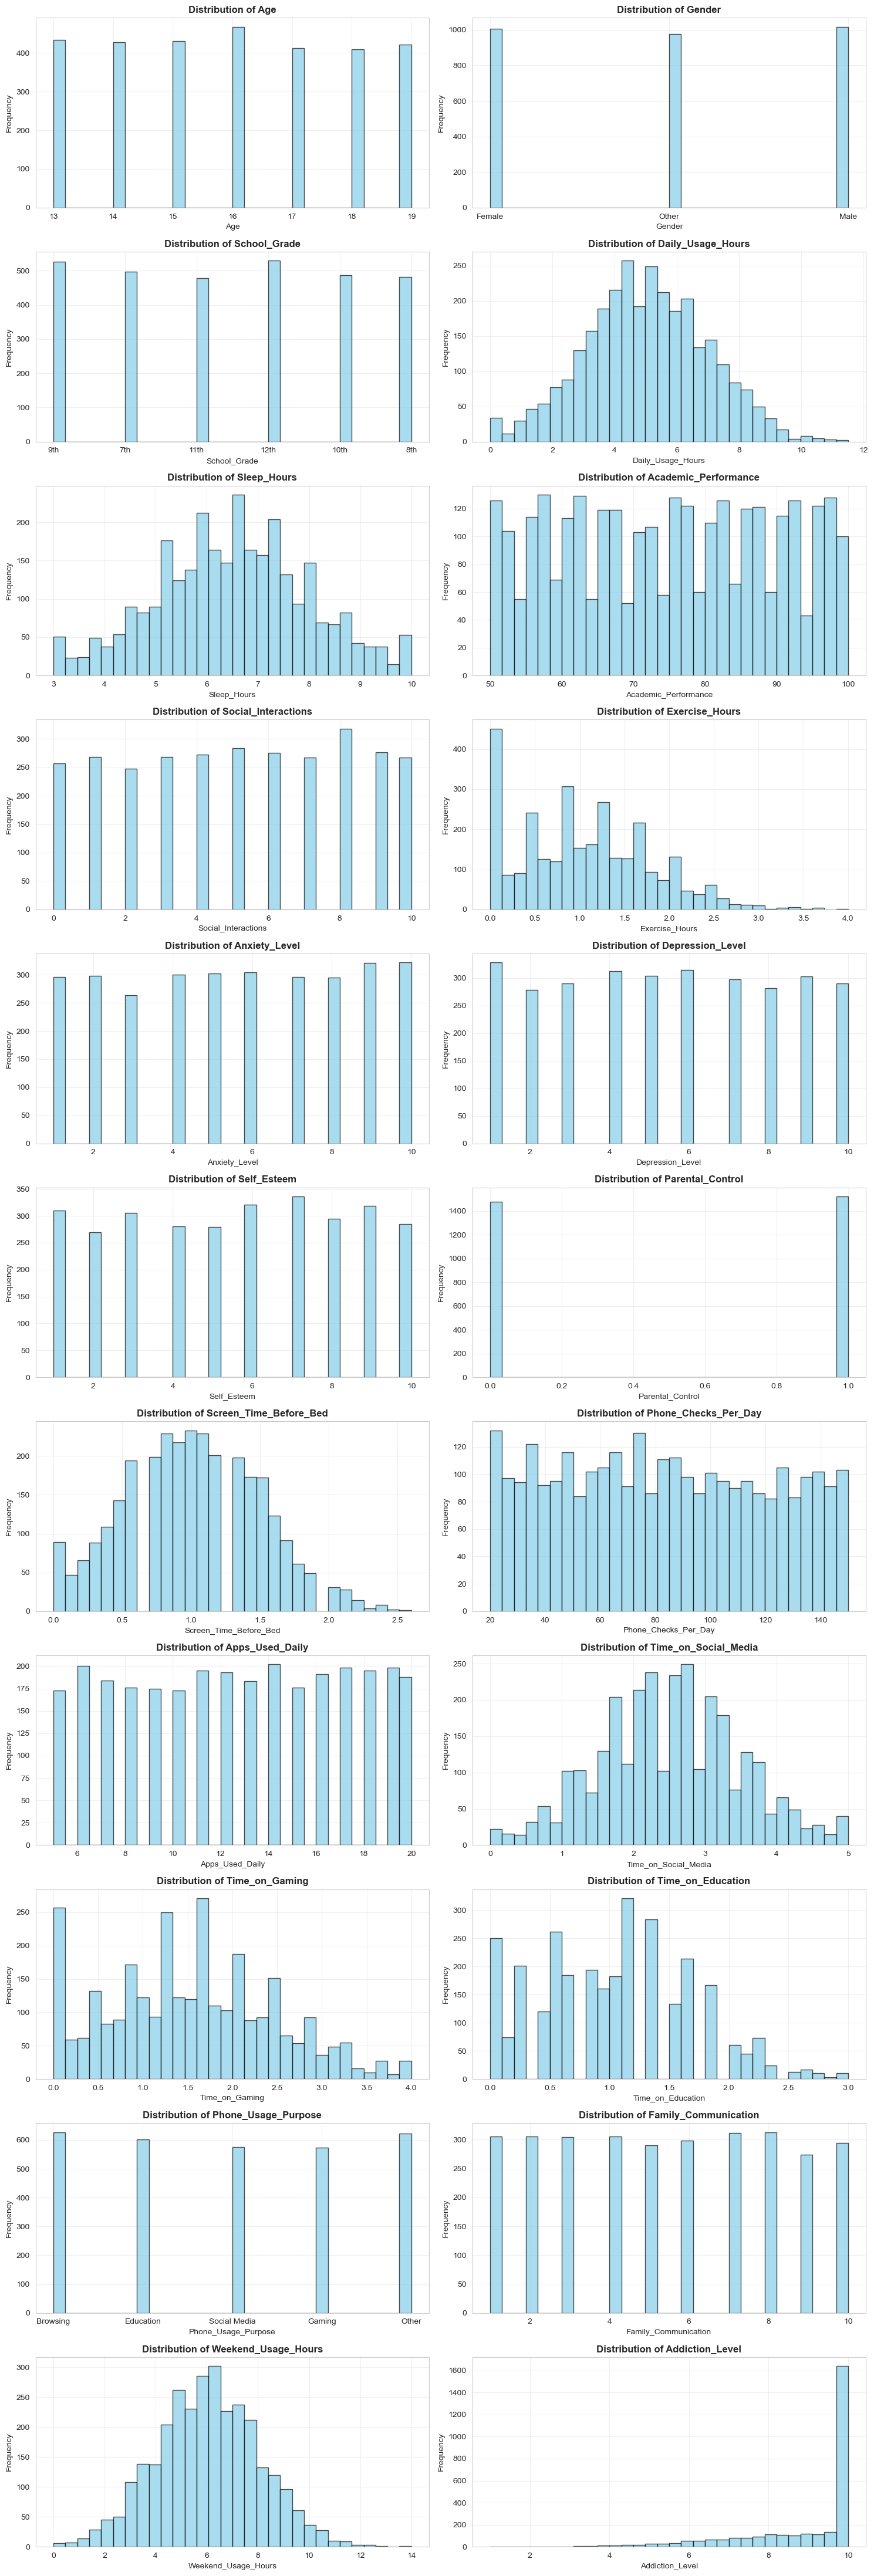

✓ Numeric distributions plotted


In [22]:
# Distribution plots for numeric columns
fig, axes = plt.subplots(nrows=(len(numeric_cols) + 1) // 2, ncols=2, figsize=(15, 4 * ((len(numeric_cols) + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide extra subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Numeric distributions plotted")

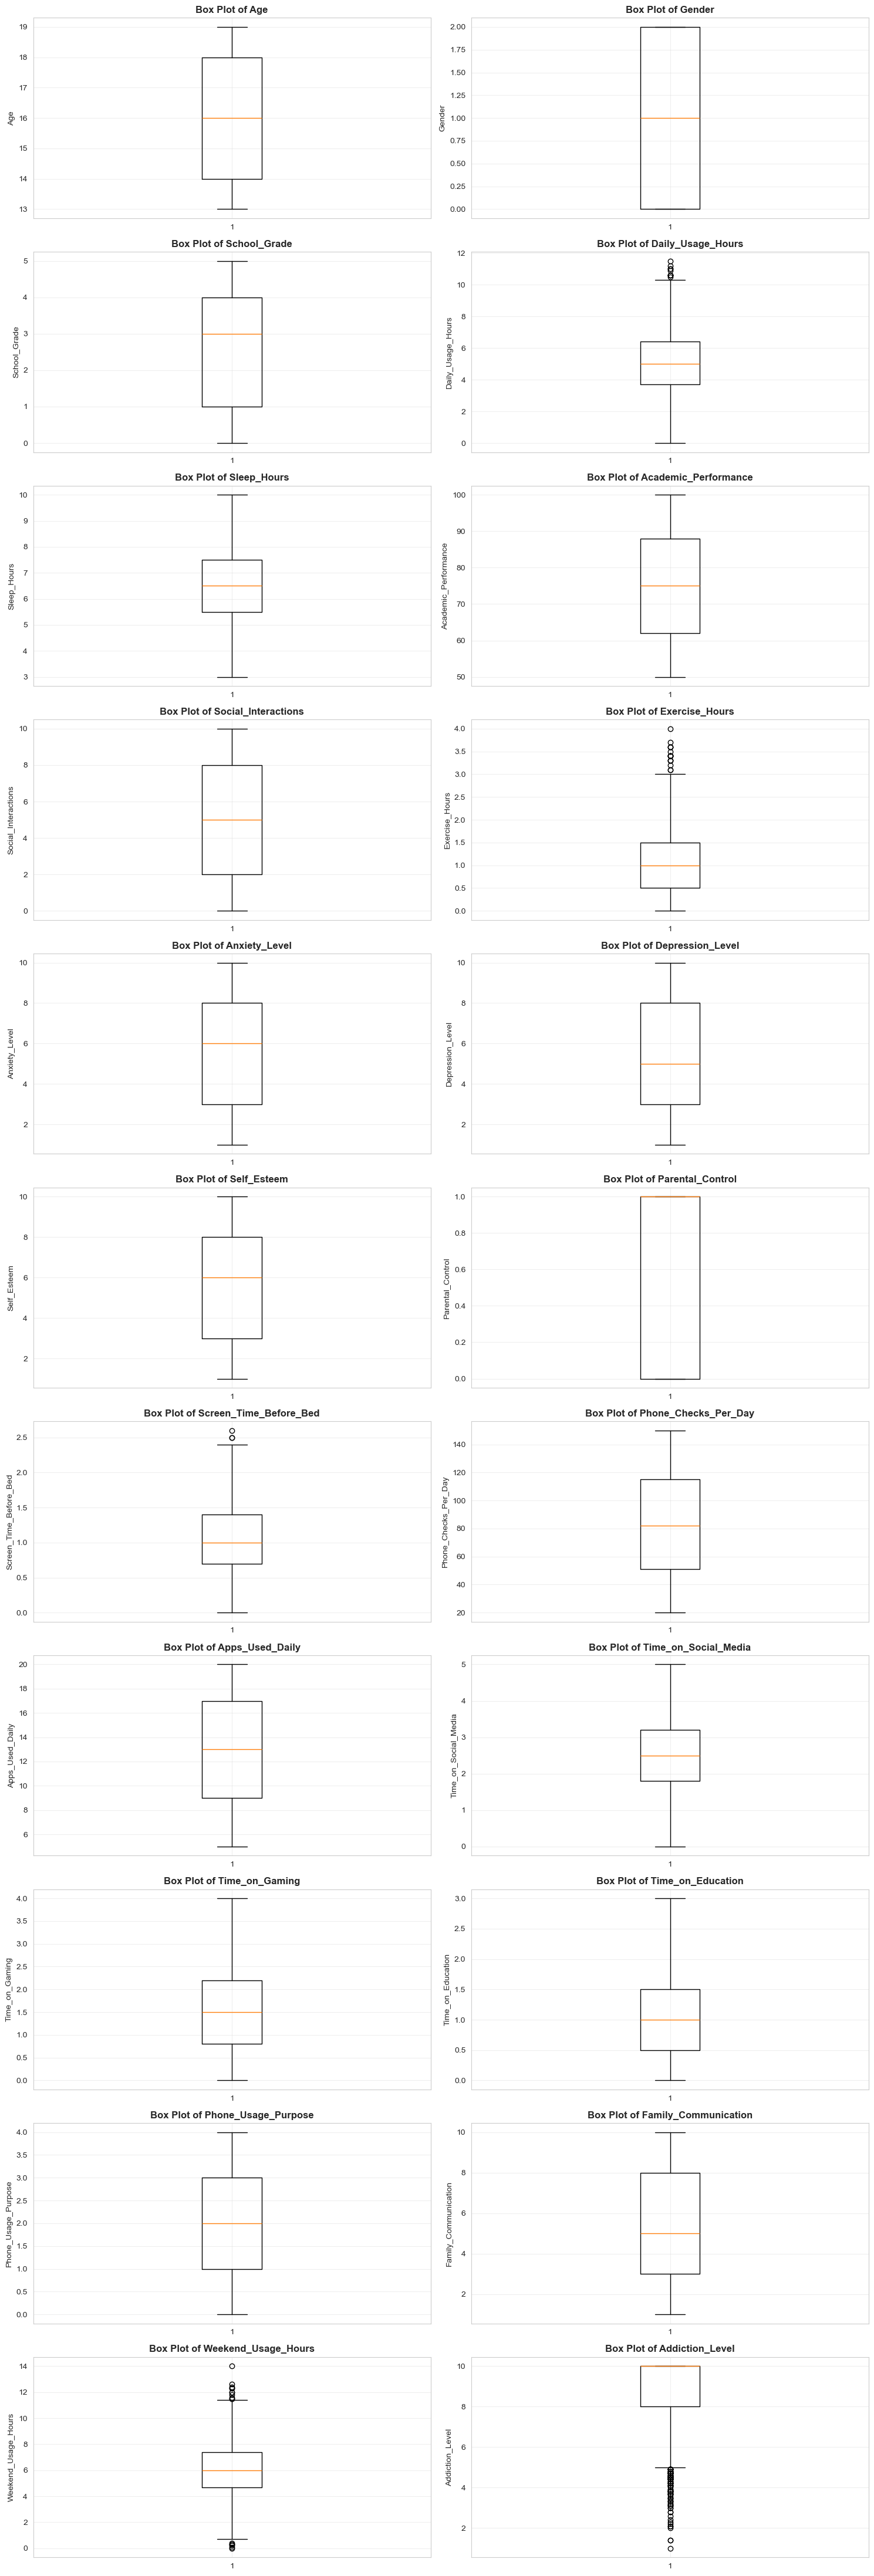

✓ Box plots generated


In [23]:
# Box plots for numeric columns
fig, axes = plt.subplots(nrows=(len(numeric_cols) + 1) // 2, ncols=2, figsize=(15, 4 * ((len(numeric_cols) + 1) // 2)))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    # use the numeric encoded dataframe when available, fallback to coercing to numeric
    try:
        data = df_label_encoded[col].dropna()
    except NameError:
        data = pd.to_numeric(df[col], errors='coerce').dropna()
    axes[idx].boxplot(data, vert=True)
    axes[idx].set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel(col)
    axes[idx].grid(alpha=0.3)

# Hide extra subplots
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("Box plots generated")


6. CORRELATION ANALYSIS

Correlation Matrix:
                             Age    Gender  School_Grade  Daily_Usage_Hours  \
Age                     1.000000 -0.013583     -0.017654           0.040689   
Gender                 -0.013583  1.000000     -0.005795          -0.020679   
School_Grade           -0.017654 -0.005795      1.000000           0.008075   
Daily_Usage_Hours       0.040689 -0.020679      0.008075           1.000000   
Sleep_Hours             0.014725 -0.008885      0.026486           0.016444   
Academic_Performance    0.023481  0.020561      0.005392           0.021345   
Social_Interactions    -0.020240 -0.004449     -0.003166          -0.030383   
Exercise_Hours          0.001187  0.008997      0.027907          -0.005930   
Anxiety_Level           0.014651 -0.004581      0.002787          -0.007221   
Depression_Level        0.052699 -0.021444     -0.002862           0.009672   
Self_Esteem            -0.033177 -0.014992      0.028563           0.006340   
Parent

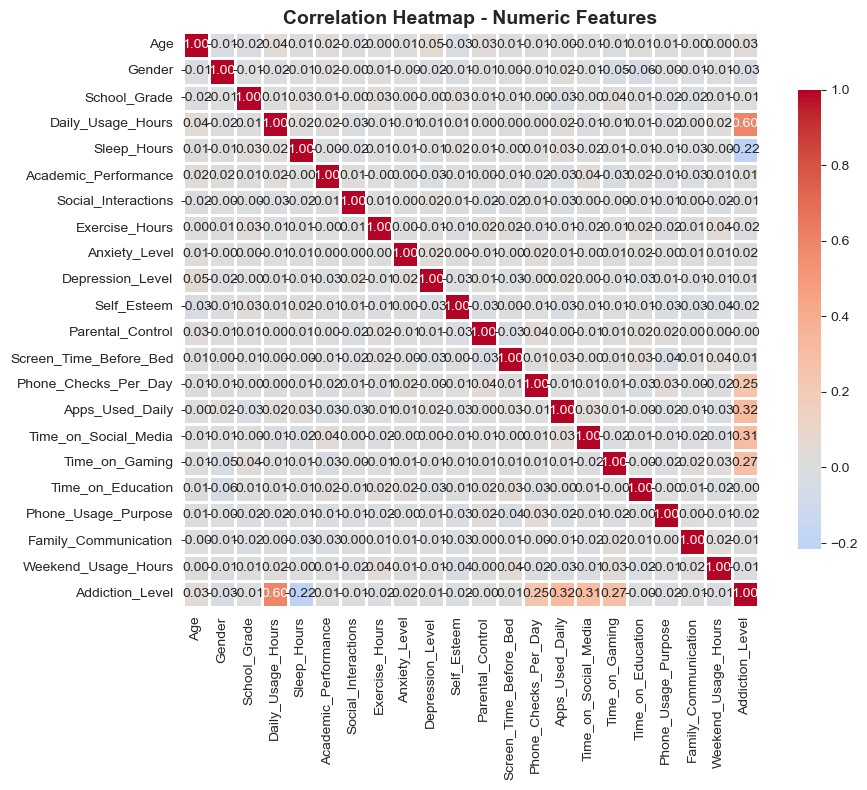


Strong Correlations (|correlation| > 0.7):
No strong correlations found


In [24]:
# Correlation analysis for numeric columns
if len(numeric_cols) > 1:
    print("\n" + "="*70)
    print("6. CORRELATION ANALYSIS")
    print("="*70)
    
    correlation_matrix = df_label_encoded[numeric_cols].corr()
    print("\nCorrelation Matrix:")
    print(correlation_matrix)
    
    # Heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
                fmt='.2f', square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Correlation Heatmap - Numeric Features', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Find strong correlations
    print("\nStrong Correlations (|correlation| > 0.7):")
    strong_corr = []
    for i in range(len(correlation_matrix.columns)):
        for j in range(i+1, len(correlation_matrix.columns)):
            if abs(correlation_matrix.iloc[i, j]) > 0.7:
                strong_corr.append({
                    'Column 1': correlation_matrix.columns[i],
                    'Column 2': correlation_matrix.columns[j],
                    'Correlation': f"{correlation_matrix.iloc[i, j]:.3f}"
                })
    
    if strong_corr:
        strong_corr_df = pd.DataFrame(strong_corr)
        print(strong_corr_df.to_string(index=False))
    else:
        print("No strong correlations found")
else:
    print("Only one numeric column - correlation analysis skipped")

## Visualization: Feature Importance (Correlation with Target)

Bar chart showing which features have the strongest relationship with phone addiction


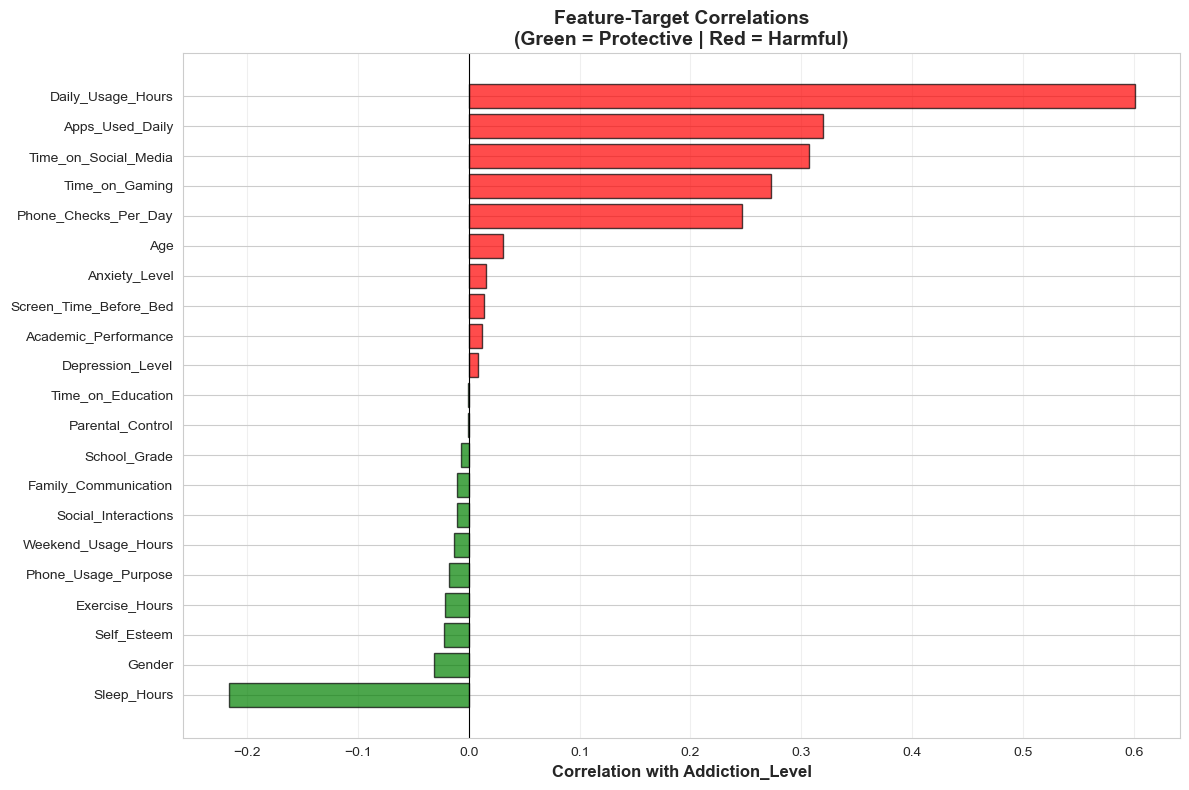

In [29]:
# Create bar chart of correlations with Addiction_Level
fig, ax = plt.subplots(figsize=(12, 8))

# Remove Addiction_Level itself
addiction_corr_sorted = addiction_correlations.drop('Addiction_Level').sort_values()

# Create colors: green for negative (protective), red for positive (harmful)
colors = ['green' if x < 0 else 'red' for x in addiction_corr_sorted]

# Plot
ax.barh(range(len(addiction_corr_sorted)), addiction_corr_sorted.values, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(addiction_corr_sorted)))
ax.set_yticklabels(addiction_corr_sorted.index)
ax.set_xlabel('Correlation with Addiction_Level', fontsize=12, fontweight='bold')
ax.set_title('Feature-Target Correlations\n(Green = Protective | Red = Harmful)', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



# STEP 1: FEATURE SELECTION

Select the most important features based on correlation analysis with the target variable (Addiction_Level)


In [32]:
print("\n" + "="*70)
print("STEP 1: FEATURE SELECTION")
print("="*70)

# Select features with correlation > 0.05 (in absolute value) with Addiction_Level
correlation_threshold = 0.05
selected_features = addiction_correlations[
    (addiction_correlations.abs() > correlation_threshold) & 
    (addiction_correlations.index != 'Addiction_Level')
].index.tolist()

print(f"\nCorrelation Threshold: {correlation_threshold}")
print(f"Total Features Available: {len(df_label_encoded.columns) - 1}")  # -1 for Addiction_Level
print(f"Features Selected: {len(selected_features)}")

print("\nSelected Features and their Correlations:")
print("-" * 70)
for feature in selected_features:
    corr_value = addiction_correlations[feature]
    direction = "(Increases Addiction)" if corr_value > 0 else "(Reduces Addiction)"
    print(f"  {feature:.<40} {corr_value:>7.4f}  {direction}")

# Prepare feature and target data
X = df_label_encoded[selected_features]
y = df_label_encoded['Addiction_Level']

print(f"\nFeatures (X) Shape: {X.shape}")
print(f"Target (y) Shape: {y.shape}")



STEP 1: FEATURE SELECTION

Correlation Threshold: 0.05
Total Features Available: 21
Features Selected: 6

 Selected Features and their Correlations:
----------------------------------------------------------------------
  Daily_Usage_Hours.......................  0.6008  ↑ (Increases Addiction)
  Apps_Used_Daily.........................  0.3193  ↑ (Increases Addiction)
  Time_on_Social_Media....................  0.3066  ↑ (Increases Addiction)
  Time_on_Gaming..........................  0.2731  ↑ (Increases Addiction)
  Phone_Checks_Per_Day....................  0.2463  ↑ (Increases Addiction)
  Sleep_Hours............................. -0.2167  ↓ (Reduces Addiction)

 Features (X) Shape: (3000, 6)
 Target (y) Shape: (3000,)


# STEP 2: DATA SCALING/NORMALIZATION

Standardize features to have mean=0 and standard deviation=1. This improves model performance and convergence.


In [34]:
from sklearn.preprocessing import StandardScaler

print("\n" + "="*70)
print("STEP 2: DATA SCALING/NORMALIZATION")
print("="*70)

# Initialize the scaler
scaler = StandardScaler()

# Fit and transform the features
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame for easier handling
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print("\nScaling Statistics:")
print("-" * 70)
print(f"Original Data - Mean: {X.mean().mean():.4f}, Std: {X.std().mean():.4f}")
print(f"Scaled Data   - Mean: {X_scaled.mean().mean():.4f}, Std: {X_scaled.std().mean():.4f}")

print(f"\nOriginal Shape: {X.shape}")
print(f"Scaled Shape: {X_scaled.shape}")

print("\nSample of Scaled Data (First 5 rows):")
print(X_scaled.head())




STEP 2: DATA SCALING/NORMALIZATION

 Scaling Statistics:
----------------------------------------------------------------------
Original Data - Mean: 18.5395, Std: 7.9544
Scaled Data   - Mean: -0.0000, Std: 1.0002

 Original Shape: (3000, 6)
 Scaled Shape: (3000, 6)

 Sample of Scaled Data (First 5 rows):
   Daily_Usage_Hours  Apps_Used_Daily  Time_on_Social_Media  Time_on_Gaming  \
0          -0.521767         1.386046              1.114095        0.187372   
1           0.245036        -0.782814             -1.416176        2.653739   
2           0.398397        -0.999700             -2.225862       -0.027094   
3          -0.981848        -1.216586              0.608041        0.080139   
4          -1.288569         1.602932              0.101987       -0.670494   

   Phone_Checks_Per_Day  Sleep_Hours  
0              0.077025    -0.261507  
1              0.341991     0.006866  
2              1.428350    -0.664066  
3              1.189881    -1.737556  
4              0.34199

# STEP 3: TRAIN-TEST SPLIT

Divide the data into training (80%) and testing (20%) sets to evaluate model generalization


In [35]:
from sklearn.model_selection import train_test_split

print("\n" + "="*70)
print("STEP 3: TRAIN-TEST SPLIT")
print("="*70)

# Split the data: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print(f"\nData Split:")
print("-" * 70)
print(f"Total Samples: {len(X_scaled)}")
print(f"Training Samples: {len(X_train)} ({len(X_train)/len(X_scaled)*100:.1f}%)")
print(f"Testing Samples: {len(X_test)} ({len(X_test)/len(X_scaled)*100:.1f}%)")

print(f"\nTraining Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Target Shape: {y_train.shape}")
print(f"Testing Target Shape: {y_test.shape}")

print("\nTarget Variable Distribution:")
print(f"Train - Mean: {y_train.mean():.2f}, Std: {y_train.std():.2f}")
print(f"Test  - Mean: {y_test.mean():.2f}, Std: {y_test.std():.2f}")




STEP 3: TRAIN-TEST SPLIT

Data Split:
----------------------------------------------------------------------
Total Samples: 3000
Training Samples: 2400 (80.0%)
Testing Samples: 600 (20.0%)

Training Features Shape: (2400, 6)
Testing Features Shape: (600, 6)
 Training Target Shape: (2400,)
 Testing Target Shape: (600,)

 Target Variable Distribution:
Train - Mean: 8.88, Std: 1.62
Test  - Mean: 8.88, Std: 1.59


# STEP 4: MODEL BUILDING

Train multiple machine learning models to predict phone addiction levels


In [44]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.svm import SVR
import warnings
warnings.filterwarnings('ignore')

xgboost_available = True
try:
    from xgboost import XGBRegressor
except ModuleNotFoundError:
    from sklearn.ensemble import GradientBoostingRegressor
    XGBRegressor = GradientBoostingRegressor
    xgboost_available = False
    print("xgboost is not installed; using GradientBoostingRegressor as a fallback.")

print("\n" + "="*70)
print("STEP 4: MODEL BUILDING")
print("="*70)

# Dictionary to store models
models = {}

# Model 1: Linear Regression
print("\nTraining Model 1: Linear Regression...")
models['Linear Regression'] = LinearRegression()
models['Linear Regression'].fit(X_train, y_train)
print("Linear Regression trained successfully")

# Model 2: Ridge Regression (with regularization)
print("\nTraining Model 2: Ridge Regression...")
models['Ridge Regression'] = Ridge(alpha=1.0)
models['Ridge Regression'].fit(X_train, y_train)
print("Ridge Regression trained successfully")

# Model 3: Random Forest
print("\nTraining Model 3: Random Forest...")
models['Random Forest'] = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
models['Random Forest'].fit(X_train, y_train)
print("Random Forest trained successfully")

# Model 4: Support Vector Machine (SVR)
print("\nTraining Model 4: Support Vector Machine (SVR)...")
models['SVR'] = SVR(kernel='rbf', C=100)
models['SVR'].fit(X_train, y_train)
print("SVR trained successfully")

# Model 5: XGBoost (or fallback)
model5_name = "XGBoost" if xgboost_available else "Gradient Boosting (fallback)"
print(f"\nTraining Model 5: {model5_name}...")

xgb_kwargs = {
    "n_estimators": 100,
    "random_state": 42,
}
if xgboost_available:
    xgb_kwargs["verbosity"] = 0

models[model5_name] = XGBRegressor(**xgb_kwargs)
models[model5_name].fit(X_train, y_train)
print(f"{model5_name} trained successfully")

print("\n" + "="*70)
print(f"All {len(models)} models trained successfully")
print("="*70)
print("\nModels Available:")
for i, model_name in enumerate(models.keys(), 1):
    print(f"   {i}. {model_name}")


xgboost is not installed; using GradientBoostingRegressor as a fallback.

STEP 4: MODEL BUILDING

Training Model 1: Linear Regression...
Linear Regression trained successfully

Training Model 2: Ridge Regression...
Ridge Regression trained successfully

Training Model 3: Random Forest...
Random Forest trained successfully

Training Model 4: Support Vector Machine (SVR)...
SVR trained successfully

Training Model 5: Gradient Boosting (fallback)...
Gradient Boosting (fallback) trained successfully

All 5 models trained successfully

Models Available:
   1. Linear Regression
   2. Ridge Regression
   3. Random Forest
   4. SVR
   5. Gradient Boosting (fallback)


# STEP 5: MODEL EVALUATION

Evaluate and compare all models using multiple performance metrics


In [49]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

print("\n" + "="*70)
print("STEP 5: MODEL EVALUATION")
print("="*70)

# Evaluate all models
results = []

for model_name, model in models.items():
    print(f"\nEvaluating {model_name}...")
    
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)
    
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    
    train_rmse = np.sqrt(train_mse)
    test_rmse = np.sqrt(test_mse)
    
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    
    results.append({
        'Model': model_name,
        'Train R²': train_r2,
        'Test R²': test_r2,
        'Train RMSE': train_rmse,
        'Test RMSE': test_rmse,
        'Train MAE': train_mae,
        'Test MAE': test_mae,
        'Overfitting': train_r2 - test_r2
    })

# Create results DataFrame
results_df = pd.DataFrame(results)

print("\n" + "="*70)
print("MODEL COMPARISON RESULTS")
print("="*70)
print(results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['Test R²'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
best_test_r2 = results_df.loc[best_model_idx, 'Test R²']

print("\n" + "="*70)
print(f"BEST MODEL: {best_model_name}")
print(f"Test R² Score: {best_test_r2:.4f}")
print("="*70)

# === Save best model and preprocessing artifacts ===
import os
from pathlib import Path
import traceback
try:
    import joblib
except Exception as e:
    joblib = None
    print(f"Warning importing joblib: {e}")
    print("Install joblib with: pip install joblib")

# Use explicit notebook folder to ensure saved files are in the workspace
save_dir = Path(r"c:\Users\rwank\Downloads\brainrot").resolve()
save_dir.mkdir(parents=True, exist_ok=True)
print(f"Saving artifacts to: {save_dir}")

# Get best model object
best_model_obj = models.get(best_model_name)
if best_model_obj is None:
    print("No best model found to save.")
else:
    # Try joblib first, fallback to pickle with verbose error reporting
    try:
        if joblib is not None:
            model_path = save_dir / 'best_model.joblib'
            joblib.dump(best_model_obj, model_path)
            print(f"Saved best model to: {model_path}")
        else:
            raise ImportError('joblib not available')
    except Exception as e:
        print(f"joblib.dump failed: {e}")
        traceback.print_exc()
        try:
            import pickle
            model_path = save_dir / 'best_model.pkl'
            with open(model_path, 'wb') as f:
                pickle.dump(best_model_obj, f)
            print(f"Saved best model with pickle to: {model_path}")
        except Exception as e2:
            print(f"Failed to save best model with pickle: {e2}")
            traceback.print_exc()

# Save scaler if available
if 'scaler' in globals() and scaler is not None:
    try:
        scaler_path = save_dir / 'scaler.joblib'
        if joblib is not None:
            joblib.dump(scaler, scaler_path)
        else:
            import pickle
            with open(scaler_path, 'wb') as f:
                pickle.dump(scaler, f)
        print(f"Saved scaler to: {scaler_path}")
    except Exception as e:
        print(f"Failed to save scaler: {e}")
        traceback.print_exc()

# Save label encoders if available
if 'label_encoders' in globals() and label_encoders:
    try:
        le_path = save_dir / 'label_encoders.joblib'
        if joblib is not None:
            joblib.dump(label_encoders, le_path)
        else:
            import pickle
            with open(le_path, 'wb') as f:
                pickle.dump(label_encoders, f)
        print(f"Saved label encoders to: {le_path}")
    except Exception as e:
        print(f"Failed to save label encoders: {e}")
        traceback.print_exc()

# === Additionally create pickle (.pkl) copies ===
import pickle
try:
    if best_model_obj is not None:
        p_model = save_dir / 'best_model.pkl'
        with open(p_model, 'wb') as f:
            pickle.dump(best_model_obj, f)
        print(f"Saved best model pickle to: {p_model}")
    if 'scaler' in globals() and scaler is not None:
        p_scaler = save_dir / 'scaler.pkl'
        with open(p_scaler, 'wb') as f:
            pickle.dump(scaler, f)
        print(f"Saved scaler pickle to: {p_scaler}")
    if 'label_encoders' in globals() and label_encoders:
        p_le = save_dir / 'label_encoders.pkl'
        with open(p_le, 'wb') as f:
            pickle.dump(label_encoders, f)
        print(f"Saved label encoders pickle to: {p_le}")
except Exception as e:
    print(f"Failed to save pickle files: {e}")
    traceback.print_exc()

# Final verification: list saved files
print("\nSaved files in save_dir:")
for p in sorted(save_dir.glob('*')):
    print(f" - {p.name}")


STEP 5: MODEL EVALUATION

Evaluating Linear Regression...

Evaluating Ridge Regression...

Evaluating Random Forest...

Evaluating SVR...

Evaluating Gradient Boosting (fallback)...

MODEL COMPARISON RESULTS
                       Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfitting
           Linear Regression  0.739499 0.736935    0.824186   0.814091   0.660580  0.651844     0.002564
            Ridge Regression  0.739499 0.736956    0.824186   0.814058   0.660584  0.651814     0.002543
               Random Forest  0.986406 0.900146    0.188278   0.501561   0.122453  0.330200     0.086260
                         SVR  0.997458 0.991783    0.081408   0.143878   0.073104  0.107881     0.005675
Gradient Boosting (fallback)  0.954308 0.908156    0.345174   0.481022   0.275581  0.374361     0.046152

BEST MODEL: SVR
Test R² Score: 0.9918
Saving artifacts to: C:\Users\rwank\Downloads\brainrot
Saved best model to: C:\Users\rwank\Downloads\brainrot\best_model.j

## Model Performance Comparison Visualization

Compare all models using key performance metrics


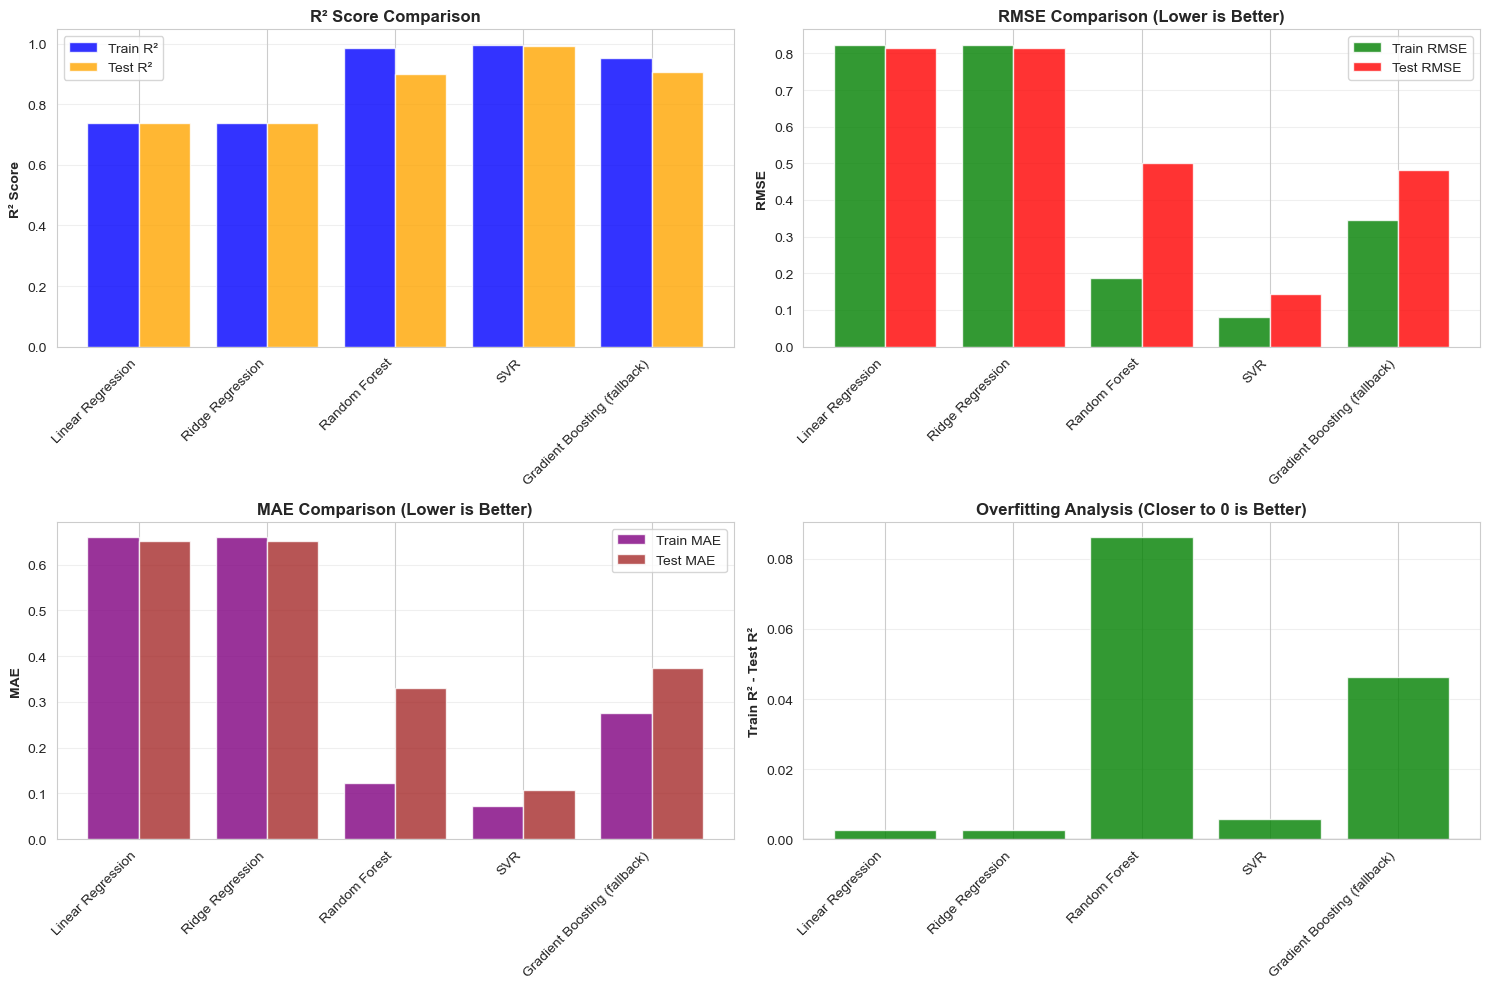

In [ ]:
# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Plot 1: R² Score Comparison
ax1 = axes[0, 0]
x_pos = np.arange(len(results_df))
ax1.bar(x_pos - 0.2, results_df['Train R²'], 0.4, label='Train R²', alpha=0.8, color='blue')
ax1.bar(x_pos + 0.2, results_df['Test R²'], 0.4, label='Test R²', alpha=0.8, color='orange')
ax1.set_ylabel('R² Score', fontweight='bold')
ax1.set_title('R² Score Comparison', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax1.legend()
ax1.grid(alpha=0.3, axis='y')

# Plot 2: RMSE Comparison
ax2 = axes[0, 1]
ax2.bar(x_pos - 0.2, results_df['Train RMSE'], 0.4, label='Train RMSE', alpha=0.8, color='green')
ax2.bar(x_pos + 0.2, results_df['Test RMSE'], 0.4, label='Test RMSE', alpha=0.8, color='red')
ax2.set_ylabel('RMSE', fontweight='bold')
ax2.set_title('RMSE Comparison (Lower is Better)', fontweight='bold')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax2.legend()
ax2.grid(alpha=0.3, axis='y')

# Plot 3: MAE Comparison
ax3 = axes[1, 0]
ax3.bar(x_pos - 0.2, results_df['Train MAE'], 0.4, label='Train MAE', alpha=0.8, color='purple')
ax3.bar(x_pos + 0.2, results_df['Test MAE'], 0.4, label='Test MAE', alpha=0.8, color='brown')
ax3.set_ylabel('MAE', fontweight='bold')
ax3.set_title('MAE Comparison (Lower is Better)', fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax3.legend()
ax3.grid(alpha=0.3, axis='y')

# Plot 4: Overfitting Analysis
ax4 = axes[1, 1]
colors = ['red' if x > 0.1 else 'green' for x in results_df['Overfitting']]
ax4.bar(x_pos, results_df['Overfitting'], alpha=0.8, color=colors)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_ylabel('Train R² - Test R²', fontweight='bold')
ax4.set_title('Overfitting Analysis (Closer to 0 is Better)', fontweight='bold')
ax4.set_xticks(x_pos)
ax4.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# --- Convert existing .joblib artifacts to .pkl copies ---
import joblib
import pickle
from pathlib import Path
save_dir = Path(r"c:\Users\rwank\Downloads\brainrot").resolve()
for jb in ['best_model.joblib','scaler.joblib','label_encoders.joblib']:
    src = save_dir / jb
    if src.exists():
        try:
            obj = joblib.load(src)
            p = src.with_suffix('.pkl')
            with open(p, 'wb') as f:
                pickle.dump(obj, f)
            print(f"Created pickle: {p.name}")
        except Exception as e:
            print(f"Failed to convert {jb}: {e}")
    else:
        print(f"{jb} not found in {save_dir}")

print('Conversion complete.')